In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.animation as animation
from scipy.signal import hilbert
from IPython.display import HTML
import os

In [2]:
# ── Load both NPZ files ───────────────────────────────────────────────
NPZ_FILES = [
    'fdtd_71nm_data_top1.npz',
    'fdtd_71nm_data_top2.npz',
]

datasets = []
for fname in NPZ_FILES:
    d = np.load(fname, allow_pickle=True)
    ds = {k: d[k] for k in d.files}
    # Scalar fields to plain Python for convenience
    for key in ['a_nm', 'L_mon', 'mon1_x', 'mon2_x', 'src_x',
                'grating_start', 'grating_end',
                'snap_region_x', 'snap_region_y',
                'sx', 'sy', 'sz',
                'LAMBDA_MIN_NM', 'LAMBDA_MAX_NM',
                'NUM_PERIODS', 'RESOLUTION']:
        if key in ds and ds[key].ndim == 0:
            ds[key] = float(ds[key])
    ds['label'] = fname.replace('.npz', '')
    datasets.append(ds)
    print(f"Loaded {fname}:")
    print(f"  a = {ds['a_nm']:.1f} nm, window = {ds['LAMBDA_MIN_NM']:.0f}–{ds['LAMBDA_MAX_NM']:.0f} nm")
    print(f"  eps_xy: {ds['eps_xy'].shape},  eps_xz: {ds['eps_xz'].shape}")
    print(f"  ey_snapshots: {ds['ey_snapshots'].shape}")

Loaded fdtd_71nm_data_top1.npz:
  a = 496.0 nm, window = 1512–1531 nm
  eps_xy: (1802, 210),  eps_xz: (1802, 100)
  ey_snapshots: (55, 1802, 210)
Loaded fdtd_71nm_data_top2.npz:
  a = 505.4 nm, window = 1542–1558 nm
  eps_xy: (1442, 166),  eps_xz: (1442, 80)
  ey_snapshots: (50, 1442, 166)


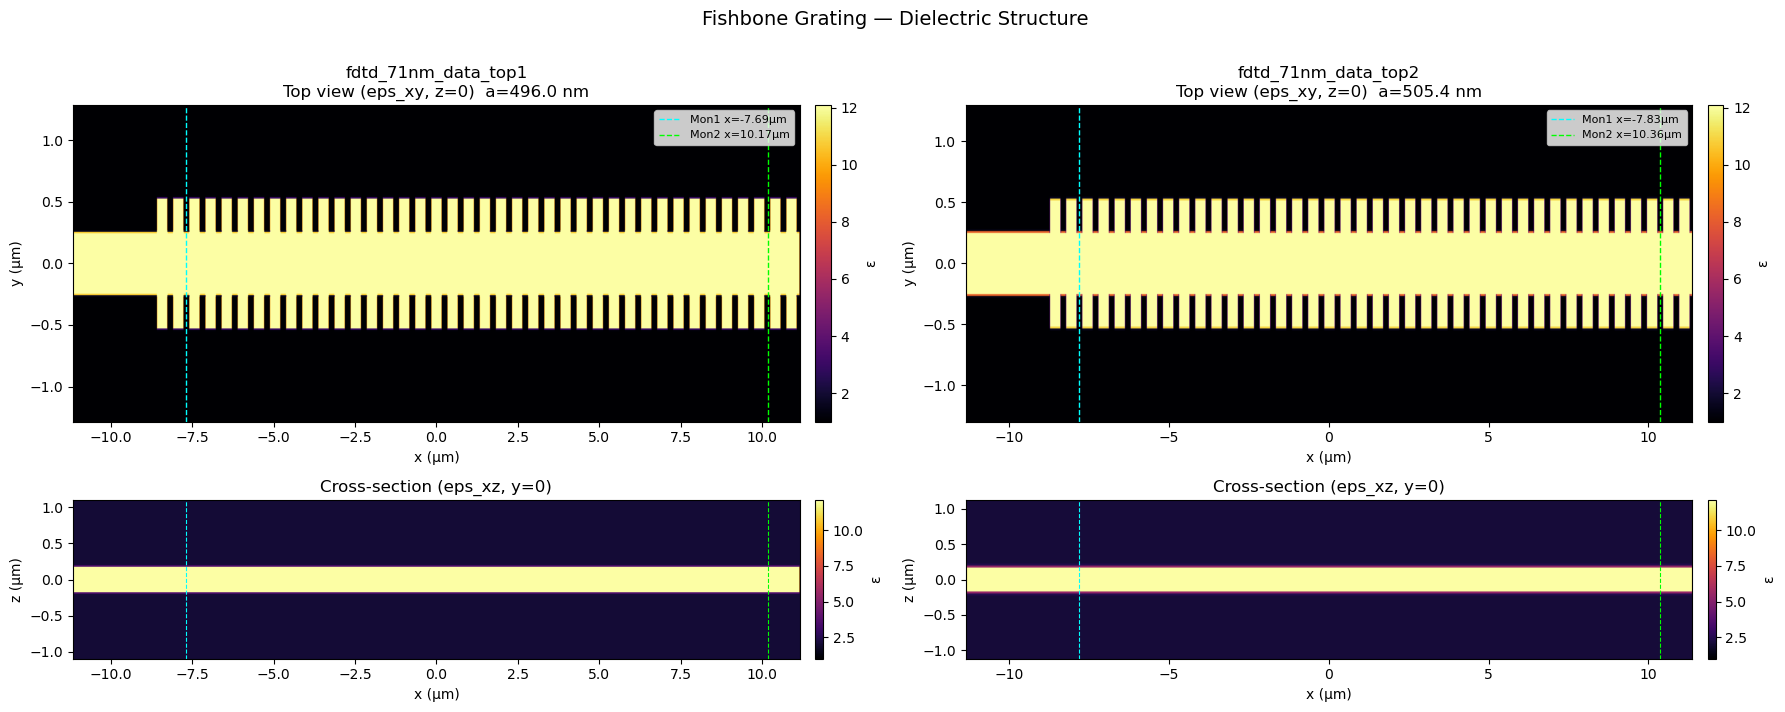

In [8]:
N_SI = 3.478
eps_Si = N_SI ** 2

fig, axes = plt.subplots(2, 2, figsize=(18, 7),
                          gridspec_kw={'height_ratios': [2, 1]})

for col, ds in enumerate(datasets):
    a  = ds['a_nm']
    rx = ds['snap_region_x'] * a / 1e3   # µm
    ry = ds['snap_region_y'] * a / 1e3   # µm
    rz = ds['sz'] * a / 1e3              # µm

    ext_xy = [-rx/2, rx/2, -ry/2, ry/2]
    ext_xz = [-rx/2, rx/2, -rz/2, rz/2]

    # --- Top view (eps_xy) ---
    ax = axes[0, col]
    im = ax.imshow(ds['eps_xy'].T, origin='lower', cmap='inferno',
                   extent=ext_xy, aspect='auto',
                   vmin=1, vmax=eps_Si)
    # Monitor positions
    m1 = ds['mon1_x'] * a / 1e3
    m2 = ds['mon2_x'] * a / 1e3
    ax.axvline(m1, color='cyan',  ls='--', lw=1, label=f'Mon1 x={m1:.2f}µm')
    ax.axvline(m2, color='lime',  ls='--', lw=1, label=f'Mon2 x={m2:.2f}µm')
    ax.set_xlabel('x (µm)')
    ax.set_ylabel('y (µm)')
    ax.set_title(f'{ds["label"]}\nTop view (eps_xy, z=0)  a={a:.1f} nm')
    ax.legend(fontsize=8, loc='upper right')
    plt.colorbar(im, ax=ax, fraction=0.03, pad=0.02, label='ε')

    # --- Cross-section (eps_xz) ---
    ax = axes[1, col]
    im2 = ax.imshow(ds['eps_xz'].T, origin='lower', cmap='inferno',
                    extent=ext_xz, aspect='auto',
                    vmin=1, vmax=eps_Si)
    ax.axvline(m1, color='cyan',  ls='--', lw=0.8)
    ax.axvline(m2, color='lime',  ls='--', lw=0.8)
    ax.set_xlabel('x (µm)')
    ax.set_ylabel('z (µm)')
    ax.set_title(f'Cross-section (eps_xz, y=0)')
    plt.colorbar(im2, ax=ax, fraction=0.03, pad=0.02, label='ε')

plt.suptitle('Fishbone Grating — Dielectric Structure', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('fdtd_geometry.png', dpi=150, bbox_inches='tight')
plt.show()

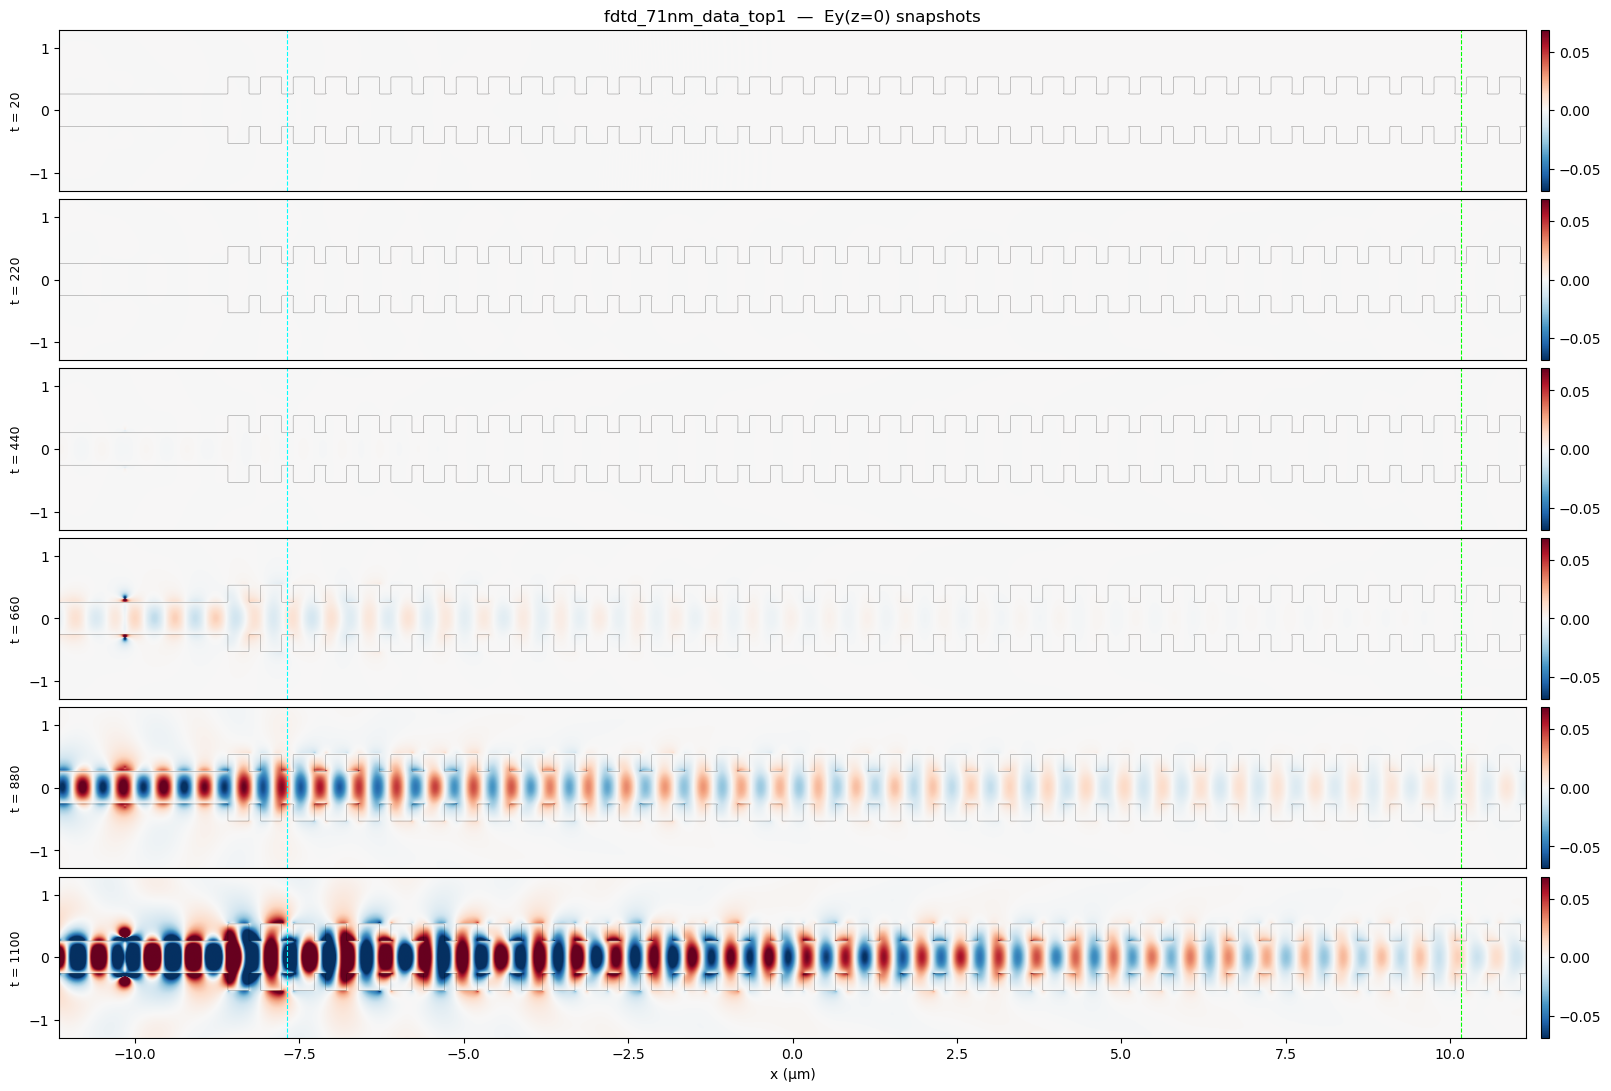

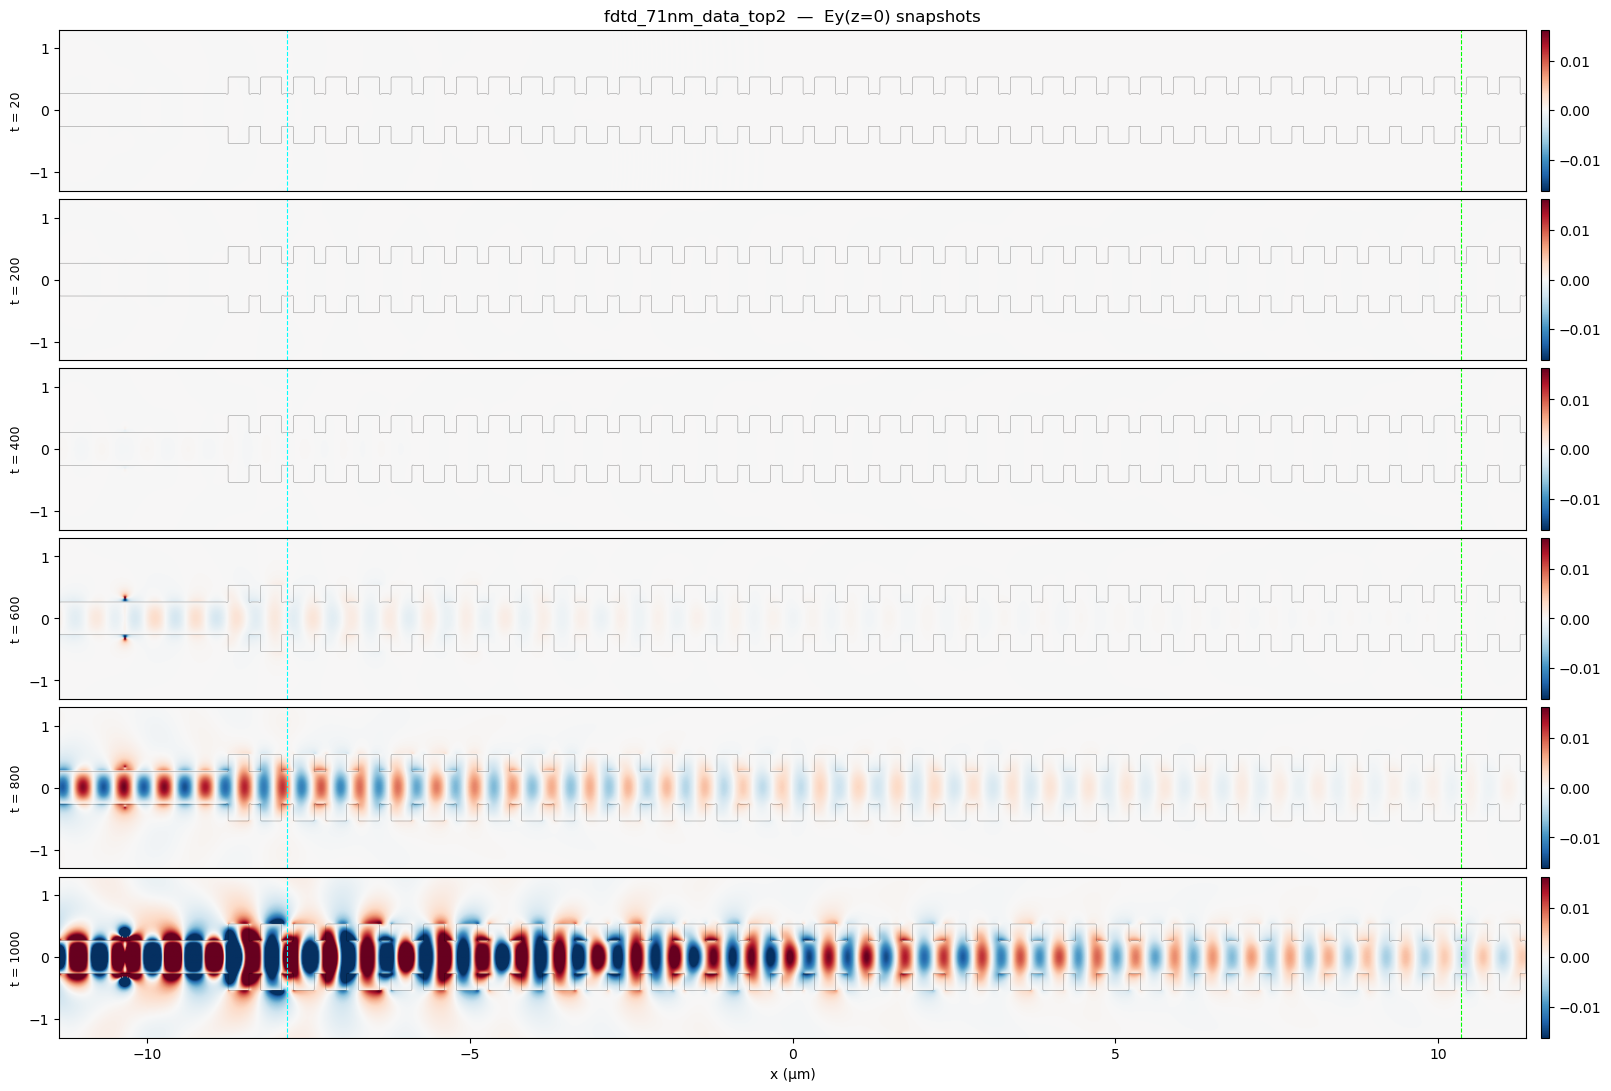

In [9]:
N_FRAMES_SHOW = 6   # frames to display per dataset

for ds in datasets:
    a  = ds['a_nm']
    rx = ds['snap_region_x'] * a / 1e3
    ry = ds['snap_region_y'] * a / 1e3
    ext_xy = [-rx/2, rx/2, -ry/2, ry/2]

    ey_stack = ds['ey_snapshots']
    vmax = np.percentile(np.abs(ey_stack), 99.5)
    n_snaps = ey_stack.shape[0]
    idxs = np.linspace(0, n_snaps - 1, N_FRAMES_SHOW, dtype=int)

    fig, axes = plt.subplots(N_FRAMES_SHOW, 1,
                             figsize=(16, 1.8 * N_FRAMES_SHOW),
                             constrained_layout=True)
    for i, idx in enumerate(idxs):
        ax = axes[i]
        im = ax.imshow(ey_stack[idx].T, origin='lower', cmap='RdBu_r',
                       extent=ext_xy, aspect='auto',
                       vmin=-vmax, vmax=vmax)
        ax.contour(ds['eps_xy'].T, levels=[eps_Si * 0.5],
                   colors='k', linewidths=0.3, alpha=0.5,
                   extent=ext_xy)
        ax.axvline(ds['mon1_x'] * a/1e3, color='cyan', ls='--', lw=0.8)
        ax.axvline(ds['mon2_x'] * a/1e3, color='lime', ls='--', lw=0.8)
        ax.set_ylabel(f"t = {ds['snap_times'][idx]:.0f}", fontsize=9)
        if i == 0:
            ax.set_title(f"{ds['label']}  —  Ey(z=0) snapshots", fontsize=12)
        if i < N_FRAMES_SHOW - 1:
            ax.set_xticks([])
        else:
            ax.set_xlabel('x (µm)')
        plt.colorbar(im, ax=ax, fraction=0.01, pad=0.01)

    plt.savefig(f"{ds['label']}_ey_snapshots.png", dpi=150, bbox_inches='tight')
    plt.show()

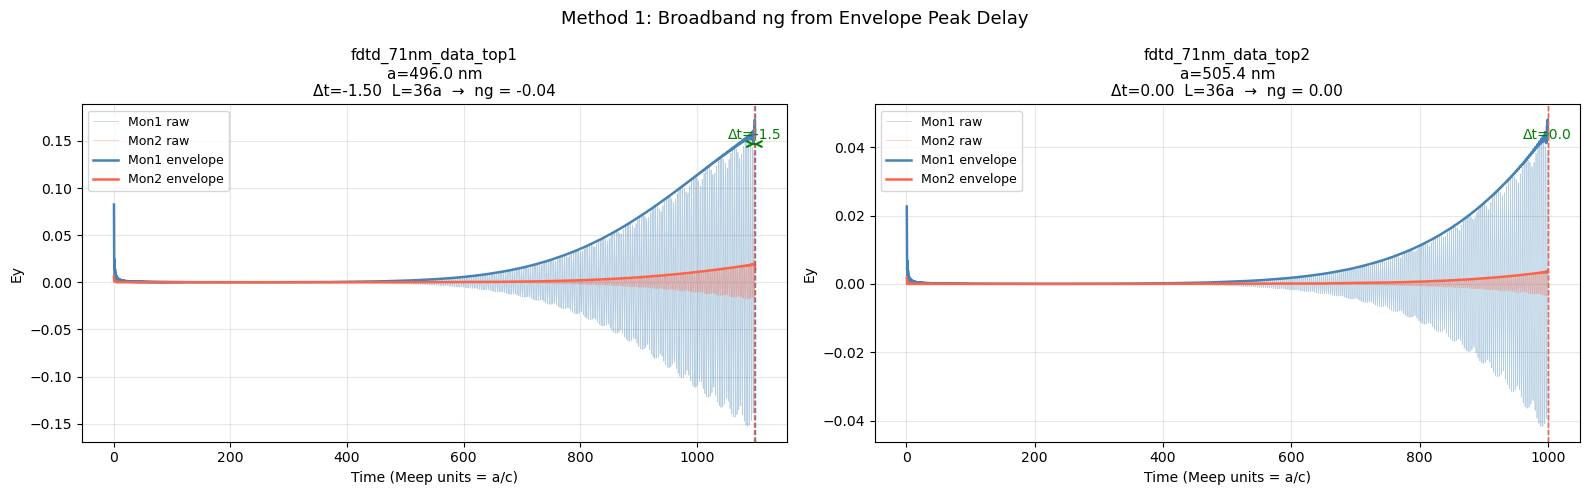


=== Method 1 Summary ===
  fdtd_71nm_data_top1: ng (broadband) = -0.042
  fdtd_71nm_data_top2: ng (broadband) = 0.000


In [10]:
results_m1 = {}   # store for later comparison

fig, axes = plt.subplots(1, 2, figsize=(16, 5), sharey=False)

for col, ds in enumerate(datasets):
    t   = ds['t_record']
    ein = ds['ey_t_in']
    eout = ds['ey_t_out']
    L   = ds['L_mon']
    a   = ds['a_nm']

    env_in  = np.abs(hilbert(ein))
    env_out = np.abs(hilbert(eout))

    t1 = t[np.argmax(env_in)]
    t2 = t[np.argmax(env_out)]
    dt_peak = t2 - t1
    ng_brd = dt_peak / L

    results_m1[ds['label']] = dict(ng=ng_brd, t1=t1, t2=t2,
                                    env_in=env_in, env_out=env_out)

    ax = axes[col]
    ax.plot(t, ein,  color='steelblue', lw=0.5, alpha=0.4, label='Mon1 raw')
    ax.plot(t, eout, color='tomato',    lw=0.5, alpha=0.4, label='Mon2 raw')
    ax.plot(t, env_in,  color='steelblue', lw=1.8, label='Mon1 envelope')
    ax.plot(t, env_out, color='tomato',    lw=1.8, label='Mon2 envelope')
    ax.axvline(t1, color='steelblue', ls='--', lw=1)
    ax.axvline(t2, color='tomato',    ls='--', lw=1)
    ymax = max(env_in.max(), env_out.max())
    ax.annotate('', xy=(t2, ymax*0.85), xytext=(t1, ymax*0.85),
                arrowprops=dict(arrowstyle='<->', color='green', lw=1.5))
    ax.text((t1+t2)/2, ymax*0.88, f'Δt={dt_peak:.1f}', ha='center',
            color='green', fontsize=10)
    ax.set_xlabel('Time (Meep units = a/c)')
    ax.set_ylabel('Ey')
    ax.set_title(
        f'{ds["label"]}\na={a:.1f} nm\n'
        f'Δt={dt_peak:.2f}  L={L:.0f}a  →  ng = {ng_brd:.2f}',
        fontsize=11)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

plt.suptitle('Method 1: Broadband ng from Envelope Peak Delay', fontsize=13)
plt.tight_layout()
plt.savefig('fdtd_ng_method1.png', dpi=150, bbox_inches='tight')
plt.show()

print('\n=== Method 1 Summary ===')
for label, r in results_m1.items():
    print(f'  {label}: ng (broadband) = {r["ng"]:.3f}')